# 04i — Isentropic Single-Variable Composite Explorer

Like `04_single_var_composite.ipynb` but on **isentropic surfaces**
(315–355 K in 5 K steps).

For each NPZ event the 3-D isobaric fields are **interpolated onto θ**
before compositing, so the bootstrap CI operates on per-event isentropic
slices.

**Two modes**:
1. **2-panel** (default): composite mean + bootstrap significance (hatched non-sig)
2. **6-panel** (`projection=True`): adds 2×2 projection onto **per-event**
   orthogonal basis (INT, PRP, DEF, Residual) with bootstrap significance
   hatching on each projected panel.

Data: `/net/flood/data2/users/x_yan/composite_blocking_tempest/onset`

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
import os, glob
from concurrent.futures import ThreadPoolExecutor

from pvtend import compute_orthogonal_basis, project_field
from pvtend.decomposition.smoothing import gaussian_smooth_nan
from pvtend.isentropic import interp_event_field_to_single_theta

## 1  Configuration & available fields

In [ ]:
DATA_ROOT  = "/net/flood/data2/users/x_yan/composite_blocking_tempest"
STAGE      = "onset"
SMOOTH_DEG = 3.0
GRID_SP    = 1.5
N_BOOT     = 1000
ALPHA      = 0.05
SEED       = 42
PV_CONTOUR = - 0 * 0.5e-6     # PV anomaly contour for mask boundary
N_CONTOUR  = 21          # number of contourf levels
N_WORKERS  = 48          # parallel workers for per-event projection

# ═══════════════════════════════════════════════════════════
#  Projection masking config
# ═══════════════════════════════════════════════════════════
MASK_SPEC = "< 0"   # restrict basis to q' < 0 region (mask)

# ── Isentropic target levels (K) ──
THETA_LEVELS = np.arange(315, 360, 5, dtype=float)  # 315, 320, … 355 K

# ── Discover available 3-D fields from a sample NPZ ──
_sample = np.load(f"{DATA_ROOT}/{STAGE}/dh=+0/" +
                  sorted(os.listdir(f"{DATA_ROOT}/{STAGE}/dh=+0"))[0])
levels_hpa = _sample["levels"]
fields_3d  = sorted(k for k in _sample.keys() if k.endswith("_3d"))

print(f"Isobaric levels (hPa): {levels_hpa}")
print(f"Target θ levels  (K) : {THETA_LEVELS}")
print(f"\n── 3-D isobaric fields ({len(fields_3d)}) ──")
for f in fields_3d:
    print(f"  {f}")

# Sanity-check θ range in the sample event
th = _sample["theta_3d"]
print(f"\n── Sample-event θ range per level ──")
for i, lev in enumerate(levels_hpa):
    print(f"  {lev:5d} hPa → θ = {np.nanmin(th[i]):.1f} – {np.nanmax(th[i]):.1f} K")

print(f"\n  USE_NEG_PV_MASK={USE_NEG_PV_MASK}")
print(f"\n  USE_NEG_PV_MASK={USE_NEG_PV_MASK}")
del _sample, th

Isobaric levels (hPa): [1000  850  700  500  400  300  250  200  100]
Target θ levels  (K) : [315. 320. 325. 330. 335. 340. 345. 350. 355.]

── 3-D isobaric fields (108) ──
  Q_3d
  pv_3d
  pv_anom_3d
  pv_anom_dp_3d
  pv_anom_dt_3d
  pv_anom_dx_3d
  pv_anom_dy_3d
  pv_bar_3d
  pv_bar_dp_3d
  pv_bar_dt_3d
  pv_bar_dx_3d
  pv_bar_dy_3d
  pv_dp_3d
  pv_dt_3d
  pv_dx_3d
  pv_dy_3d
  q_3d
  t_3d
  t_dt_3d
  theta_3d
  theta_dot_3d
  theta_dt_3d
  u_3d
  u_anom_3d
  u_anom_pv_anom_dx_3d
  u_anom_pv_bar_dx_3d
  u_bar_3d
  u_bar_pv_anom_dx_3d
  u_bar_pv_bar_dx_3d
  u_div_anom_3d
  u_div_anom_pv_anom_dx_3d
  u_div_anom_pv_bar_dx_3d
  u_div_bar_3d
  u_div_bar_pv_anom_dx_3d
  u_div_bar_pv_bar_dx_3d
  u_div_dry_3d
  u_div_dry_pv_anom_dx_3d
  u_div_dry_pv_bar_dx_3d
  u_div_emanuel_moist_3d
  u_div_emanuel_moist_pv_anom_dx_3d
  u_div_emanuel_moist_pv_bar_dx_3d
  u_div_moist_3d
  u_div_moist_pv_anom_dx_3d
  u_div_moist_pv_bar_dx_3d
  u_div_qg_moist_3d
  u_div_qg_moist_pv_anom_dx_3d
  u_div_qg_moist_

## Isentropic interpolation — MetPy-aligned algorithm

Each NPZ event contains 3-D fields on $N_p$ isobaric levels
$\{p_1, p_2, \dots, p_{N_p}\}$ (here 1000, 850, 700, 500, 400, 300, 250, 200, 100 hPa).
The potential-temperature field $\theta(p)$ is also stored at every grid column
$(j, i)$.

**Goal.** Given a target isentropic level $\theta^*$ (e.g. 330 K), obtain
$\phi(\theta^*)$ for any 3-D field $\phi$ at every horizontal grid point.

### What is needed

| Quantity | Symbol | Shape | Units |
|---|---|---|---|
| Pressure levels | $p_k$ | $(N_p,)$ | hPa |
| Temperature | $T(p_k, j, i)$ | $(N_p, N_y, N_x)$ | K |
| Potential temperature | $\theta = T(P_0/p)^\kappa$ | $(N_p, N_y, N_x)$ | K |
| Target isentropic surfaces | $\theta^*$ | $(N_\theta,)$ | K |
| Field to interpolate | $\phi(p_k, j, i)$ | $(N_p, N_y, N_x)$ | various |

### Algorithm (Ziv & Alpert 1994, as in MetPy `isentropic_interpolation`)

The implementation in `pvtend.isentropic` follows MetPy v1.7 ([source](https://github.com/Unidata/MetPy/blob/v1.7.1/src/metpy/calc/thermo.py#L3023-L3190)):

1. **Sort** pressure levels in descending order (surface → top).

2. **Compute** potential temperature at every grid point:
$$\theta = T \left(\frac{P_0}{p}\right)^\kappa, \quad \kappa = R_d / c_{pd} \approx 0.286$$

3. For each target $\theta^*$, **find bounding indices** $m, m+1$ such that
   $\theta_m \leq \theta^* \leq \theta_{m+1}$.

4. **Assume** temperature varies linearly with $\ln p$ between the bounding levels:
$$T(\ln p) = a \cdot \ln p + b$$
where:
$$a = \frac{T_{m+1} - T_m}{\ln p_{m+1} - \ln p_m}, \quad
b = T_{m+1} - a \cdot \ln p_{m+1}$$

5. **Newton-Raphson** iteration to solve for $p^*$ on the $\theta^*$ surface:
$$\theta^* = T(\ln p) \cdot \left(\frac{P_0}{p}\right)^\kappa
  = (a \ln p + b) \cdot P_0^\kappa \cdot e^{-\kappa \ln p}$$

   Define:
$$f(\ln p) = \theta^* - (a \ln p + b) \cdot P_0^\kappa \cdot e^{-\kappa \ln p}$$
$$f'(\ln p) = P_0^\kappa \cdot e^{-\kappa \ln p} \cdot (\kappa T - a)$$

   Update:
$$\ln p_{n+1} = \ln p_n - \frac{f}{f'}$$

6. Once $p^*$ is known, **interpolate** additional fields linearly onto the
   isentropic surface (column-wise `np.interp` against sorted $\theta$).

If $\theta^*$ is **outside** the column's $\theta$ range → NaN (no extrapolation).

### Why this is better than simple θ-interpolation

- The Newton-Raphson approach correctly models the **non-linear Poisson relationship** between $T$ and $p$, rather than assuming $\phi$ varies linearly with $\theta$.
- Additional fields are interpolated via $\theta$ as the vertical coordinate, which is meteorologically consistent.

### Reference
Ziv, B. & Alpert, P. (1994). *Beitr. Phys. Atmosph.*, 67, 221–230.
MetPy docs: [isentropic_interpolation](https://unidata.github.io/MetPy/latest/api/generated/metpy.calc.isentropic_interpolation.html)

## 2  Core helpers

In [3]:
from zipfile import BadZipFile


def _load_npz(path):
    try:
        return dict(np.load(path))
    except (BadZipFile, EOFError, OSError):
        return None


def load_events(dh, stage=STAGE):
    """Load all events at a given dh → list[dict] (skips bad files)."""
    sign = "+" if dh >= 0 else ""
    d = f"{DATA_ROOT}/{stage}/dh={sign}{dh}"
    files = sorted(glob.glob(os.path.join(d, "track_*.npz")))
    if not files:
        return []
    with ThreadPoolExecutor(max_workers=8) as pool:
        results = list(pool.map(_load_npz, files))
    good = [r for r in results if r is not None]
    n_bad = len(results) - len(good)
    if n_bad:
        print(f"  ⚠ dh={dh}: skipped {n_bad} corrupt/incomplete NPZ files")
    return good


# ─────────────────────────────────────────────────────
# Isentropic field extraction (using pvtend.isentropic)
# ─────────────────────────────────────────────────────
def get_field_isen(event, var_spec, theta_level):
    """Extract a 2-D isentropic field from one event.

    Uses ``pvtend.isentropic.interp_event_field_to_single_theta``
    which follows the MetPy / Ziv-Alpert (1994) algorithm:
      - column-wise interpolation with θ sorted ascending
      - NaN for out-of-range θ* (no extrapolation)

    Parameters
    ----------
    event : dict — loaded NPZ event.
    var_spec : str or list[str]
        Field name(s) with optional '-' prefix for negation.  Summed.
        '_3d' suffix is appended automatically.
    theta_level : float (K)

    Returns
    -------
    (ny, nx) array.
    """
    if isinstance(var_spec, str):
        var_spec = [var_spec]

    theta_3d = event["theta_3d"]   # (nlev, ny, nx)

    total = None
    for vs in var_spec:
        negate = vs.startswith("-")
        name = vs.lstrip("-").strip()
        key_3d = name if name.endswith("_3d") else name + "_3d"

        # Interpolate using the MetPy-aligned pvtend function
        arr = interp_event_field_to_single_theta(
            theta_3d, event[key_3d], theta_level)

        if negate:
            arr = -arr
        total = arr.copy() if total is None else total + arr
    return total


def bootstrap_sig_isen(events, var_spec, theta_level,
                       n_boot=N_BOOT, alpha=ALPHA, seed=SEED):
    """Composite mean + bootstrap CI on an isentropic surface.

    Returns (mean_2d, sig_mask) — sig_mask=True where CI excludes zero.
    """
    print(f"  Interpolating {len(events)} events to θ={theta_level} K ...")
    stack = np.array([get_field_isen(e, var_spec, theta_level) for e in events])
    N = stack.shape[0]
    rng = np.random.default_rng(seed)

    boot = np.empty((n_boot, *stack.shape[1:]))
    for b in range(n_boot):
        idx = rng.integers(0, N, size=N)
        boot[b] = np.nanmean(stack[idx], axis=0)

    lo = np.nanpercentile(boot, 100 * alpha / 2, axis=0)
    hi = np.nanpercentile(boot, 100 * (1 - alpha / 2), axis=0)
    mean = np.nanmean(stack, axis=0)
    sig_mask = ~((lo <= 0) & (hi >= 0))
    return mean, sig_mask


print("Helpers defined (using pvtend.isentropic).")

Helpers defined (using pvtend.isentropic).


## 2b  Sanity check — 3-D θ structure & isentropic interpolation

Event shape: (9, 29, 49)  (nlev=9, ny=29, nx=49)
Pressure levels: [1000  850  700  500  400  300  250  200  100]


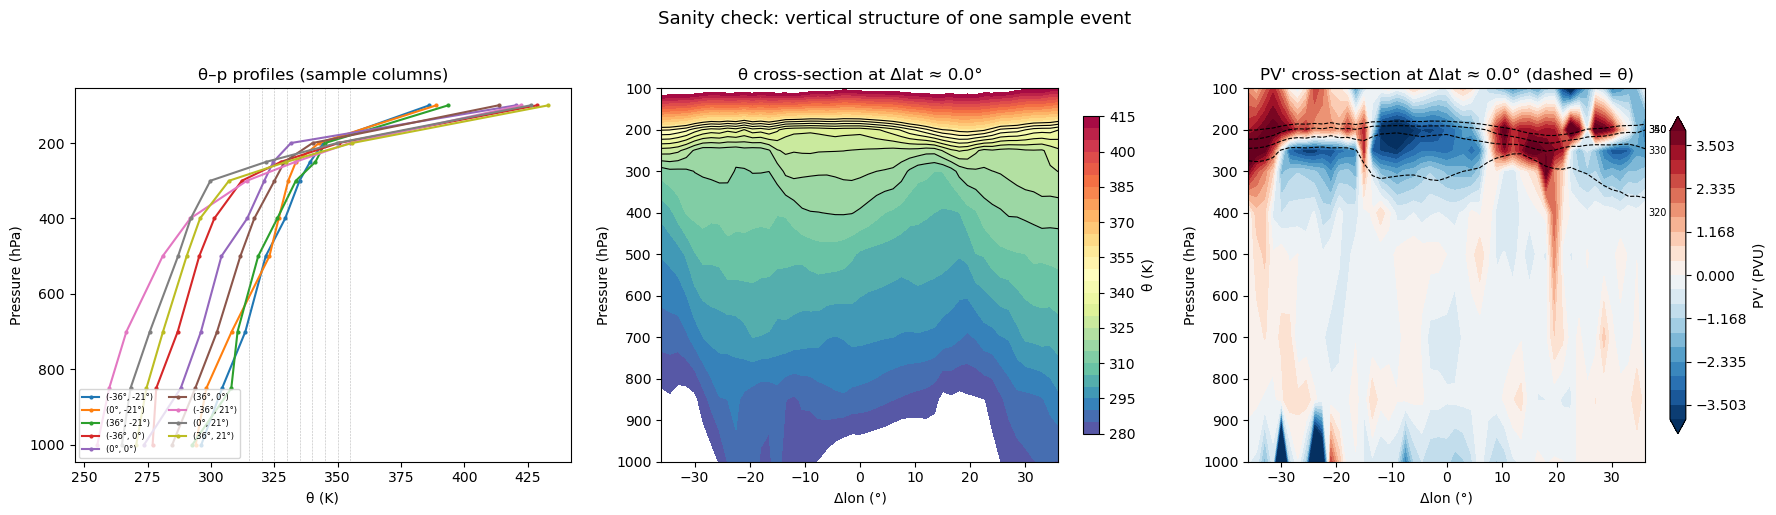

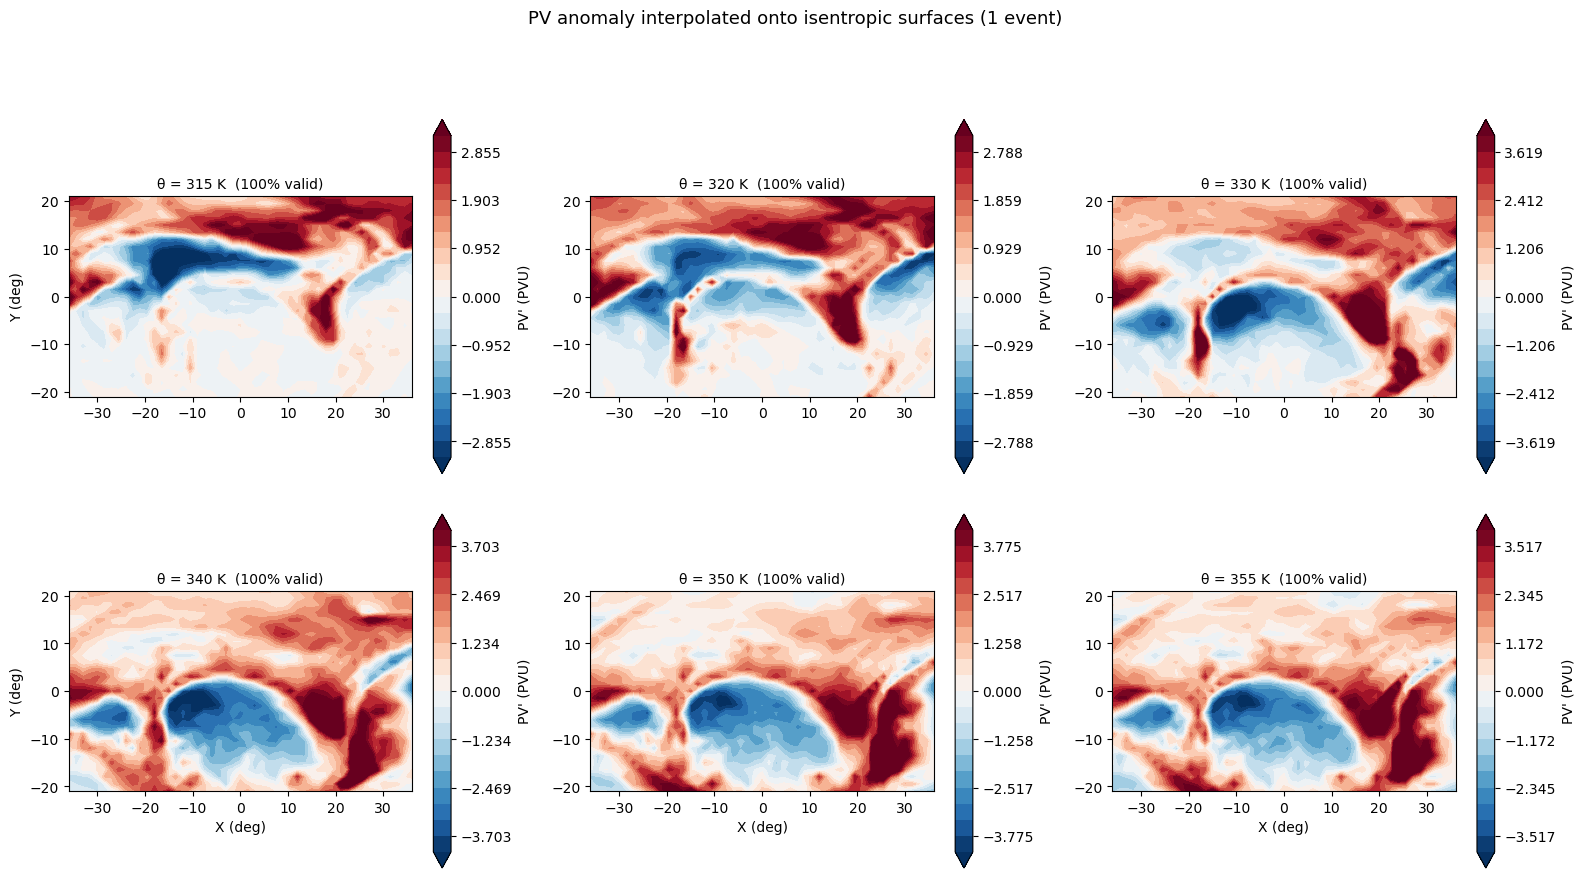

Sanity check complete.


In [4]:
# ── Load one sample event for visualization ──────────────────────────
_ev = load_events(dh=0)[0]
theta_3d = _ev["theta_3d"]          # (nlev, ny, nx)
pv_3d    = _ev["pv_anom_3d"]        # (nlev, ny, nx)
X_rel    = _ev["X_rel"]
Y_rel    = _ev["Y_rel"]
x_rel    = X_rel[0, :]
y_rel    = Y_rel[:, 0]
nlev, ny, nx = theta_3d.shape

print(f"Event shape: {theta_3d.shape}  (nlev={nlev}, ny={ny}, nx={nx})")
print(f"Pressure levels: {levels_hpa}")

# ── Panel 1: θ(p) profiles at 9 grid points (3×3 sub-grid) ──────────
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# (a) θ–p profiles at selected columns
ax = axes[0]
jj = np.linspace(0, ny - 1, 3, dtype=int)
ii = np.linspace(0, nx - 1, 3, dtype=int)
for j in jj:
    for i in ii:
        th_col = theta_3d[:, j, i]
        ax.plot(th_col, levels_hpa, marker=".", ms=4,
                label=f"({x_rel[i]:.0f}°, {y_rel[j]:.0f}°)")
# Overlay target θ levels as horizontal bands
for tl in THETA_LEVELS:
    ax.axvline(tl, color="grey", lw=0.4, ls=":")
ax.set_xlabel("θ (K)")
ax.set_ylabel("Pressure (hPa)")
ax.invert_yaxis()
ax.set_title("θ–p profiles (sample columns)")
ax.legend(fontsize=6, ncol=2, loc="lower left")

# (b) Cross-section: θ along the central latitude (y_rel ≈ 0)
ax = axes[1]
j_mid = ny // 2
th_slice = theta_3d[:, j_mid, :]   # (nlev, nx)
cf = ax.contourf(x_rel, levels_hpa, th_slice,
                 levels=np.arange(280, 420, 5), cmap="Spectral_r")
for tl in THETA_LEVELS:
    ax.contour(x_rel, levels_hpa, th_slice, levels=[tl],
               colors="k", linewidths=0.8)
ax.invert_yaxis()
ax.set_xlabel("Δlon (°)")
ax.set_ylabel("Pressure (hPa)")
ax.set_title(f"θ cross-section at Δlat ≈ {y_rel[j_mid]:.1f}°")
plt.colorbar(cf, ax=ax, label="θ (K)", shrink=0.85)

# (c) Cross-section: PV anomaly along central latitude
ax = axes[2]
pv_slice = pv_3d[:, j_mid, :] * 1e6  # → PVU
vmax_pv = np.nanpercentile(np.abs(pv_slice), 95)
cf2 = ax.contourf(x_rel, levels_hpa, pv_slice,
                  levels=np.linspace(-vmax_pv, vmax_pv, 21),
                  cmap="RdBu_r", extend="both")
for tl in [320, 330, 340, 350]:
    ax.contour(x_rel, levels_hpa, th_slice, levels=[tl],
               colors="k", linewidths=0.8, linestyles="--")
    # Label the θ contour
    ax.text(x_rel[-1] + 0.5, levels_hpa[np.argmin(np.abs(th_slice[:, -1] - tl))],
            f"{tl}", fontsize=7, va="center")
ax.invert_yaxis()
ax.set_xlabel("Δlon (°)")
ax.set_ylabel("Pressure (hPa)")
ax.set_title(f"PV' cross-section at Δlat ≈ {y_rel[j_mid]:.1f}° (dashed = θ)")
plt.colorbar(cf2, ax=ax, label="PV' (PVU)", shrink=0.85)

fig.suptitle("Sanity check: vertical structure of one sample event", fontsize=13, y=1.02)
fig.tight_layout()
plt.show()

# ── Panel 2: PV anomaly interpolated onto multiple θ surfaces ────────
theta_show = [315, 320, 330, 340, 350, 355]
n_th = len(theta_show)
fig2, axes2 = plt.subplots(2, 3, figsize=(16, 9))

for idx, tl in enumerate(theta_show):
    ax = axes2.flat[idx]
    pv_isen = get_field_isen(_ev, "pv_anom", tl)
    valid_frac = 100 * np.mean(np.isfinite(pv_isen))
    pv_isen_pvu = pv_isen * 1e6
    vmax_i = np.nanpercentile(np.abs(pv_isen_pvu[np.isfinite(pv_isen_pvu)]), 95) \
             if np.any(np.isfinite(pv_isen_pvu)) else 1.0
    vmax_i = max(vmax_i, 1e-6)
    im = ax.contourf(X_rel, Y_rel, pv_isen_pvu,
                     levels=np.linspace(-vmax_i, vmax_i, 21),
                     cmap="RdBu_r", extend="both")
    ax.set_title(f"θ = {tl} K  ({valid_frac:.0f}% valid)", fontsize=10)
    ax.set_aspect("equal")
    if idx % 3 == 0:
        ax.set_ylabel("Y (deg)")
    if idx >= 3:
        ax.set_xlabel("X (deg)")
    plt.colorbar(im, ax=ax, shrink=0.8, label="PV' (PVU)")

fig2.suptitle("PV anomaly interpolated onto isentropic surfaces (1 event)",
              fontsize=13, y=1.02)
fig2.tight_layout()
plt.show()

del _ev
print("Sanity check complete.")

## 2c  Sanity check — ω magnitude reduction on isentropic surfaces

On isobaric surfaces $\omega$ includes both adiabatic and diabatic vertical motion.
On isentropic surfaces, $\dot\theta = 0$ for adiabatic flow, so only diabatic
heating/cooling contributes — we expect **much smaller** magnitudes in the θ coordinate.

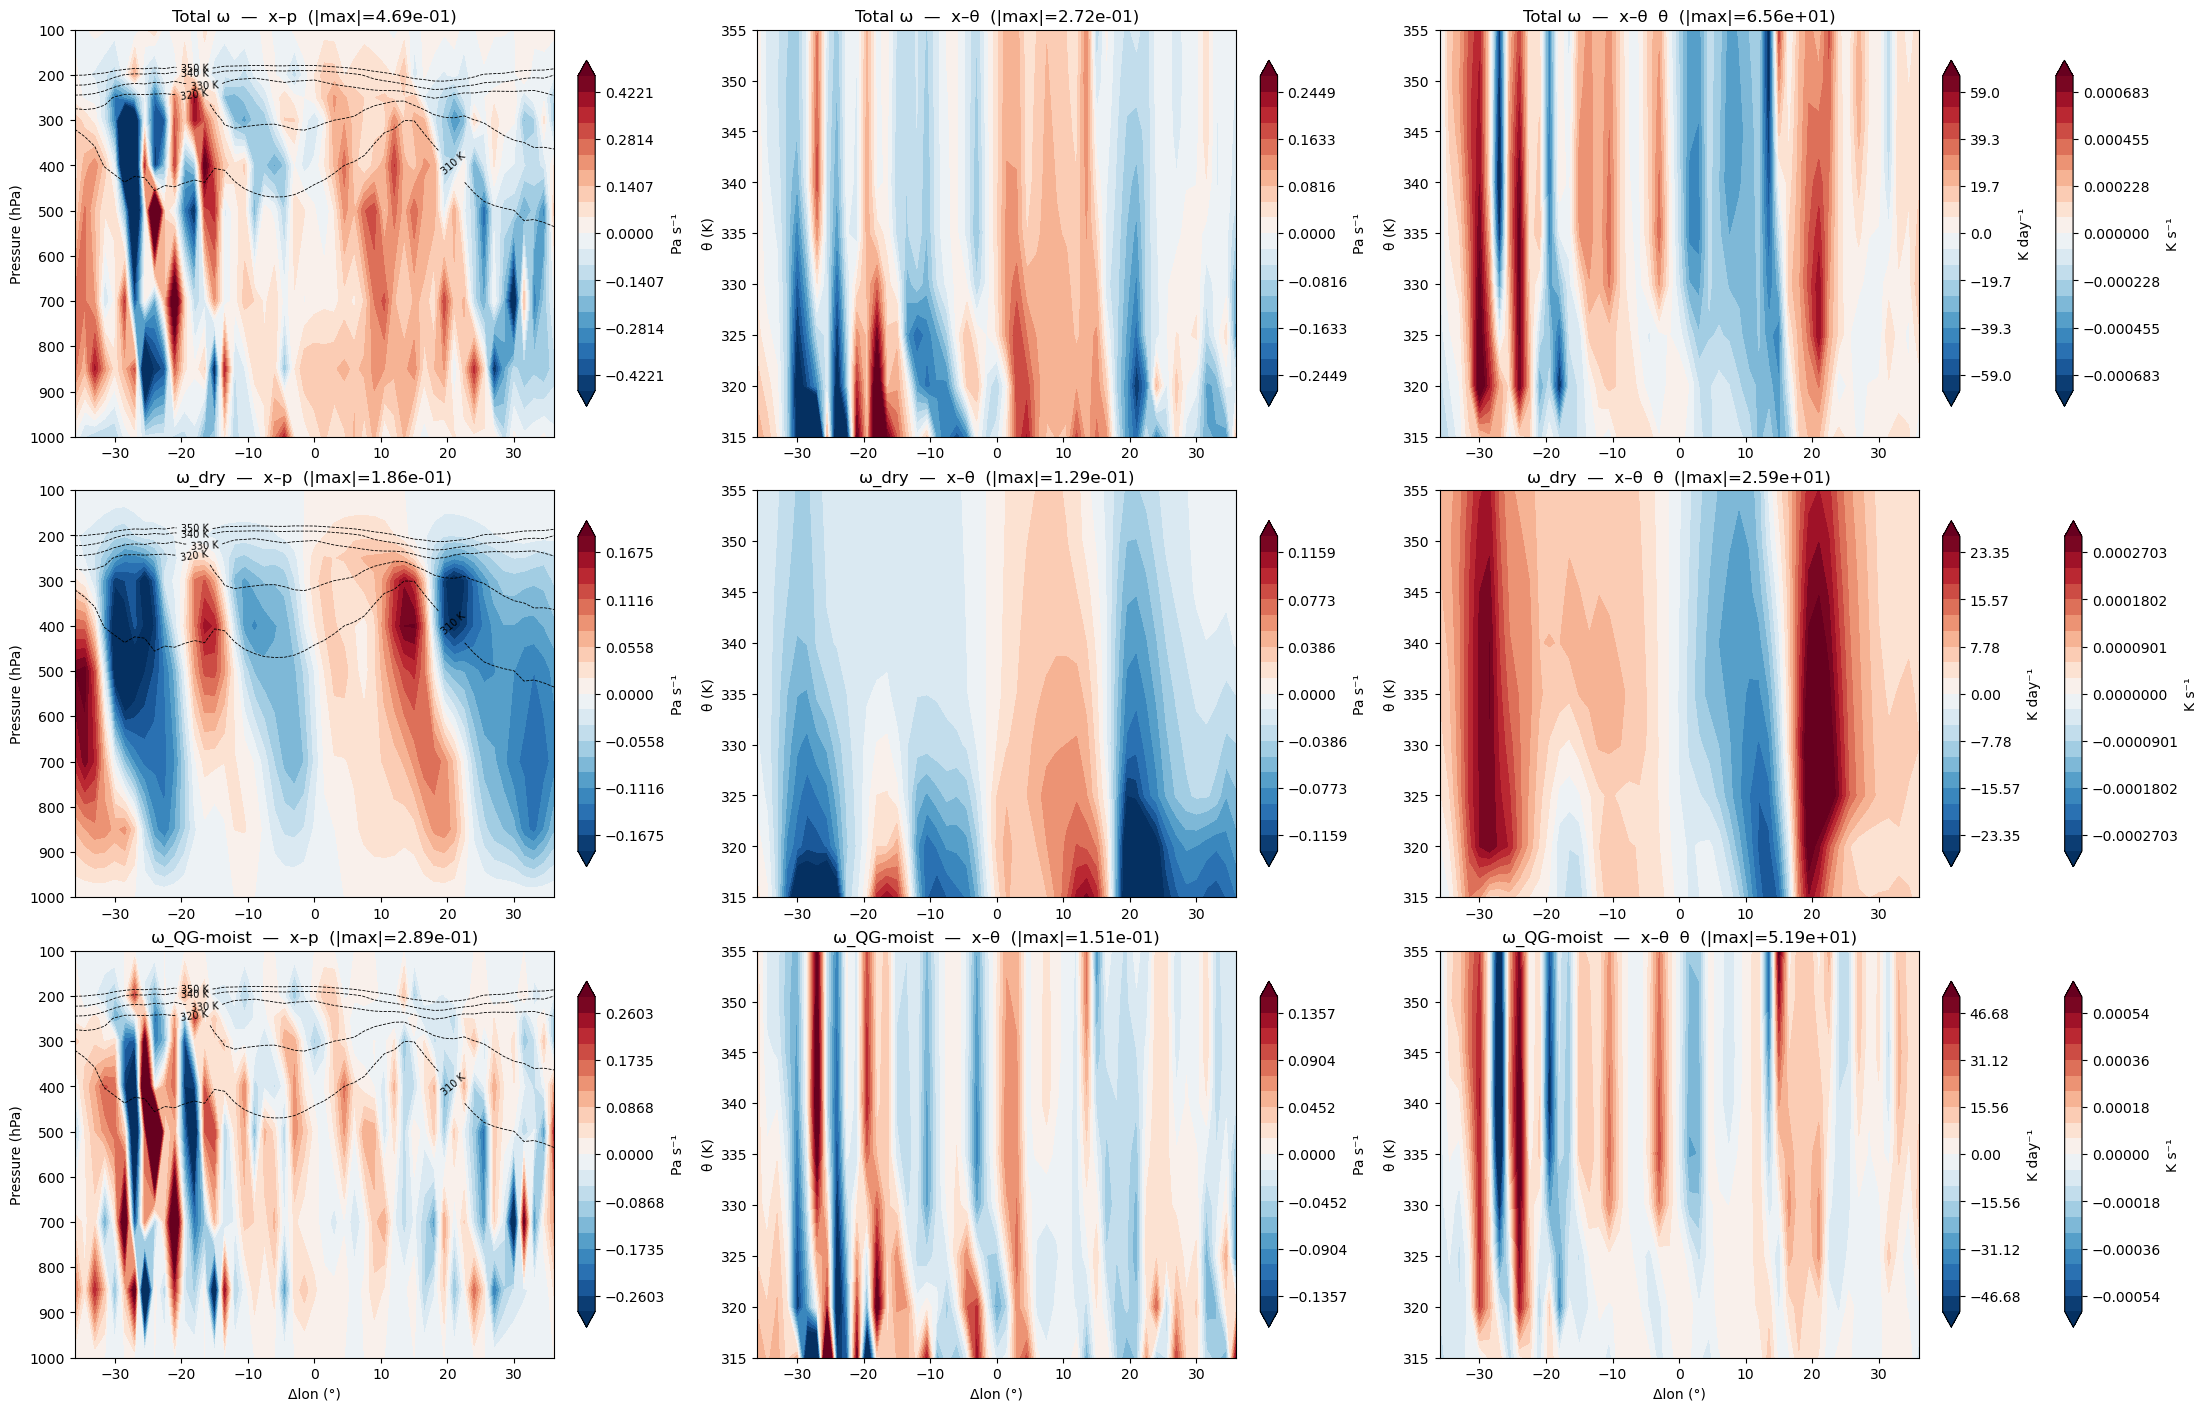

In [20]:
# ── Compare ω cross-sections: isobaric (x–p) vs isentropic (x–θ) ────
_ev = load_events(dh=0)[0]
theta_3d = _ev["theta_3d"]          # (nlev, ny, nx)
X_rel    = _ev["X_rel"]
Y_rel    = _ev["Y_rel"]
x_rel    = X_rel[0, :]
y_rel    = Y_rel[:, 0]
nlev, ny, nx = theta_3d.shape
j_mid = ny // 2                     # centre latitude row

w_names  = ["w",       "w_dry",  "w_qg_moist"]
w_labels = ["Total ω", "ω_dry",  "ω_QG-moist"]

# Prepare isentropic cross-section along centre latitude for each field
theta_slice = theta_3d[:, j_mid, :]  # (nlev, nx) — for isobaric panel

# ── Compute ∂θ/∂p on isobaric levels (K/Pa) for ω→θ̇ conversion ──
p_Pa = levels_hpa * 100.0  # hPa → Pa, shape (nlev,)
dtheta_dp = np.gradient(theta_3d, p_Pa, axis=0)  # (nlev, ny, nx), K/Pa

fig, axes = plt.subplots(3, 3, figsize=(22, 14), constrained_layout=True)

for row, (wname, wlabel) in enumerate(zip(w_names, w_labels)):
    key3d = wname + "_3d"
    field_3d = _ev[key3d]              # (nlev, ny, nx)

    # ── Col 0: isobaric x–p cross-section (Pa/s) ──
    ax_p = axes[row, 0]
    slice_p = field_3d[:, j_mid, :]    # (nlev, nx)  — Pa/s
    vmax = np.nanpercentile(np.abs(slice_p), 97)
    vmax = max(vmax, 1e-10)
    cf_p = ax_p.contourf(x_rel, levels_hpa, slice_p,
                         levels=np.linspace(-vmax, vmax, 21),
                         cmap="RdBu_r", extend="both")
    for tl in [310, 320, 330, 340, 350]:
        cs = ax_p.contour(x_rel, levels_hpa, theta_slice,
                         levels=[tl], colors="k", linewidths=0.6, linestyles="--")
        ax_p.clabel(cs, fmt=f"{tl} K", fontsize=7, inline=True)
    ax_p.invert_yaxis()
    ax_p.set_ylabel("Pressure (hPa)")
    ax_p.set_title(f"{wlabel}  —  x–p  (|max|={vmax:.2e})")
    plt.colorbar(cf_p, ax=ax_p, shrink=0.85, label="Pa s⁻¹")

    # ── Col 1: isentropic x–θ cross-section (Pa/s) ──
    ax_th = axes[row, 1]
    th_levels = THETA_LEVELS
    slice_isen = np.full((len(th_levels), nx), np.nan)
    for ti, th_val in enumerate(th_levels):
        isen_2d = get_field_isen(_ev, wname, th_val)   # (ny, nx)
        slice_isen[ti, :] = isen_2d[j_mid, :]

    vmax_th = np.nanpercentile(np.abs(slice_isen[np.isfinite(slice_isen)]), 97) \
              if np.any(np.isfinite(slice_isen)) else 1e-10
    vmax_th = max(vmax_th, 1e-10)
    cf_th = ax_th.contourf(x_rel, th_levels, slice_isen,
                           levels=np.linspace(-vmax_th, vmax_th, 21),
                           cmap="RdBu_r", extend="both")
    ax_th.set_ylabel("θ (K)")
    ax_th.set_title(f"{wlabel}  —  x–θ  (|max|={vmax_th:.2e})")
    plt.colorbar(cf_th, ax=ax_th, shrink=0.85, label="Pa s⁻¹")

    # ── Col 2: isentropic x–θ converted to K/s  (θ̇ = ω · ∂θ/∂p) ──
    # Compute θ̇ on isobaric levels, then interpolate to isentropic
    thetadot_3d = field_3d * dtheta_dp   # (nlev, ny, nx), K/s
    # Temporarily inject as a synthetic _3d key for get_field_isen
    _ev["_thetadot_tmp_3d"] = thetadot_3d
    ax_ks = axes[row, 2]
    slice_ks = np.full((len(th_levels), nx), np.nan)
    for ti, th_val in enumerate(th_levels):
        ks_2d = get_field_isen(_ev, "_thetadot_tmp", th_val)
        slice_ks[ti, :] = ks_2d[j_mid, :]

    vmax_ks = np.nanpercentile(np.abs(slice_ks[np.isfinite(slice_ks)]), 97) \
    # ── Col 2: isentropic x–θ converted to K/day  (θ̇ = ω · ∂θ/∂p) ──
    vmax_ks = max(vmax_ks, 1e-10)
    cf_ks = ax_ks.contourf(x_rel, th_levels, slice_ks,
                           levels=np.linspace(-vmax_ks, vmax_ks, 21),
                           cmap="RdBu_r", extend="both")
    ax_ks.set_ylabel("θ (K)")
    ax_ks.set_title(f"{wlabel}  —  x–θ  θ̇  (|max|={vmax_ks:.2e})")
    plt.colorbar(cf_ks, ax=ax_ks, shrink=0.85, label="K s⁻¹")
    del _ev["_thetadot_tmp_3d"]

    slice_kd = slice_ks * 86400.0        # K/s → K/day

    vmax_kd = np.nanpercentile(np.abs(slice_kd[np.isfinite(slice_kd)]), 97) \
              if np.any(np.isfinite(slice_kd)) else 1e-10
    vmax_kd = max(vmax_kd, 1e-10)
    cf_ks = ax_ks.contourf(x_rel, th_levels, slice_kd,
                           levels=np.linspace(-vmax_kd, vmax_kd, 21),
                           cmap="RdBu_r", extend="both")
    ax_ks.set_ylabel("θ (K)")
    ax_ks.set_title(f"{wlabel}  —  x–θ  θ̇  (|max|={vmax_kd:.2e})")
    plt.colorbar(cf_ks, ax=ax_ks, shrink=0.85, label="K day⁻¹")
    _ev.pop("_thetadot_tmp_3d", None)

    # bottom row x-labels
    if row == 2:
        ax_p.set_xlabel("Δlon (°)")
        ax_th.set_xlabel("Δlon (°)")
        ax_ks.set_xlabel("Δlon (°)")

    # Print magnitude ratios

## 3  Main plotting function

In [ ]:
smooth = lambda f: gaussian_smooth_nan(f, smoothing_deg=SMOOTH_DEG, grid_spacing=GRID_SP)


def _project_single_event_isen(event, var_spec, theta_level, x_rel, y_rel):
    """Build per-event isentropic basis and project → maps + coefficients."""
    pv_anom = get_field_isen(event, "pv_anom", theta_level)
    pv_dx   = get_field_isen(event, "pv_anom_dx", theta_level)
    pv_dy   = get_field_isen(event, "pv_anom_dy", theta_level)

    # Skip if too many NaNs
    if np.sum(np.isfinite(pv_anom)) < 10:
        return None

    try:
        basis_e = compute_orthogonal_basis(
            pv_anom, pv_dx, pv_dy, x_rel, y_rel,
            mask=MASK_SPEC,
            apply_smoothing=True,
            smoothing_deg=SMOOTH_DEG,
            grid_spacing=GRID_SP,
            interp_alpha=1,
        )
    except Exception:
        return None

    fld = get_field_isen(event, var_spec, theta_level)
    fld_s = smooth(fld)
    p = project_field(fld_s, basis_e)
    return {
        "int": p["int"], "prop": p["prop"], "def": p["def"], "resid": p["resid"],
        "beta": p["beta"], "ax": p["ax"], "ay": p["ay"],
        "gamma": p["gamma"], "rmse": p["rmse"],
    }


def plot_var(var_spec, dh=0, theta_level=330.0, projection=False,
             n_boot=N_BOOT, alpha=ALPHA, seed=SEED, figsize_scale=1.0,
             n_workers=N_WORKERS):
    """Composite + bootstrap plot on an isentropic surface.

    Parameters
    ----------
    var_spec : str or list[str]
        Field name(s) with optional '-' prefix for negation.  Summed.
    dh : int
        Lifecycle hour.
    theta_level : float
        Isentropic level (K).
    projection : bool
        If True, add 2×2 projection rows (3-row / 6-panel figure).
        Uses per-event basis with parallel workers + bootstrap sig on
        projected panels.
    n_workers : int
        Parallel workers for per-event projection (default N_WORKERS).
    """
    if isinstance(var_spec, str):
        var_spec = [var_spec]

    # ── 1. Load events ──
    evs = load_events(dh)
    N = len(evs)
    if N == 0:
        print(f"No events at dh={dh}")
        return
    X_rel = evs[0]["X_rel"]
    Y_rel = evs[0]["Y_rel"]
    x_rel = X_rel[0, :]
    y_rel = Y_rel[:, 0]

    # ── 2. Composite mean + bootstrap on θ surface ──
    print(f"Computing bootstrap (N={N}, n_boot={n_boot}, θ={theta_level} K) ...")
    mean_fld, sig_mask = bootstrap_sig_isen(evs, var_spec, theta_level,
                                            n_boot, alpha, seed)
    pct_sig = 100 * np.nanmean(sig_mask)
    print(f"  {pct_sig:.1f}% significant at {100*(1-alpha):.0f}%")

    # PV anomaly composite on the same θ surface (for contour)
    pv_anom_mean = np.nanmean(
        [get_field_isen(e, "pv_anom", theta_level) for e in evs], axis=0)

    # ── Label ──
    var_label = " + ".join(var_spec)

    # ── 3. Projection via per-event basis (parallel) ──
    proj = None
    proj_sig = {}
    if projection:
        from functools import partial as _partial

        print(f"  Per-event isentropic projection ({n_workers} workers) ...")
        worker = _partial(
            _project_single_event_isen,
            var_spec=var_spec, theta_level=theta_level,
            x_rel=x_rel, y_rel=y_rel,
        )
        with ThreadPoolExecutor(max_workers=n_workers) as pool:
            results = list(pool.map(worker, evs))

        good = [r for r in results if r is not None]
        n_good = len(good)
        print(f"  {n_good}/{N} events projected successfully")

        if n_good > 0:
            # Stack per-event projected maps
            proj_maps = {k: np.array([g[k] for g in good])
                         for k in ["int", "prop", "def", "resid"]}

            # Composite mean of projected maps
            proj = {k: np.nanmean(proj_maps[k], axis=0)
                    for k in proj_maps}

            # Mean scalar coefficients
            for k in ["beta", "ax", "ay", "gamma", "rmse"]:
                proj[k] = np.nanmean([g[k] for g in good])

            # Bootstrap sig on each projected panel
            rng = np.random.default_rng(seed)
            for pkey in ["int", "prop", "def", "resid"]:
                stack_p = proj_maps[pkey]
                n_p = stack_p.shape[0]
                boot_p = np.empty((n_boot, *stack_p.shape[1:]))
                for b in range(n_boot):
                    idx = rng.integers(0, n_p, size=n_p)
                    boot_p[b] = np.nanmean(stack_p[idx], axis=0)
                lo_p = np.nanpercentile(boot_p, 100 * alpha / 2, axis=0)
                hi_p = np.nanpercentile(boot_p, 100 * (1 - alpha / 2), axis=0)
                proj_sig[pkey] = ~((lo_p <= 0) & (hi_p >= 0))

            print(f"  Projection: β={proj['beta']:.3e}  αx={proj['ax']:.3f}  "
                  f"αy={proj['ay']:.3f}  γ={proj['gamma']:.3e}")

    # ── 4. Plot ──
    n_rows = 3 if projection else 1
    fig = plt.figure(figsize=(14 * figsize_scale, 5 * n_rows * figsize_scale))
    gs = GridSpec(n_rows, 2, figure=fig, hspace=0.35, wspace=0.25)

    # Colour scale
    finite = mean_fld[np.isfinite(mean_fld)]
    if finite.size == 0:
        print("⚠ No finite values — θ level may be out of range for most events.")
        return None
    vmax = float(np.nanpercentile(np.abs(finite), 95))
    vmax = max(vmax, 1e-30)
    clevels = np.linspace(-vmax, vmax, N_CONTOUR)

    # --- Row 1, Left: Composite mean ---
    ax0 = fig.add_subplot(gs[0, 0])
    im0 = ax0.contourf(X_rel, Y_rel, mean_fld, levels=clevels,
                        cmap="RdBu_r", extend="both")
    ax0.contour(X_rel, Y_rel, pv_anom_mean,
                levels=[PV_CONTOUR], colors="white", linewidths=2.5)
    ax0.set_title(f"Composite Mean  (N={N})", fontsize=11, fontweight="bold")
    ax0.set_ylabel("Y (deg)"); ax0.set_xlabel("X (deg)")
    ax0.set_aspect("equal")
    plt.colorbar(im0, ax=ax0, shrink=0.85)

    # --- Row 1, Right: Bootstrap significance ---
    ax1 = fig.add_subplot(gs[0, 1])
    im1 = ax1.contourf(X_rel, Y_rel, mean_fld, levels=clevels,
                        cmap="RdBu_r", extend="both")
    ax1.contour(X_rel, Y_rel, pv_anom_mean,
                levels=[PV_CONTOUR], colors="white", linewidths=2.5)
    ax1.contourf(X_rel, Y_rel, (~sig_mask).astype(float),
                 levels=[0.5, 1.5], hatches=["xxx"], colors="none", zorder=5)
    ax1.set_title(f"Bootstrap sig ({100*(1-alpha):.0f}%)  "
                  f"Hatch=n.s.  ({pct_sig:.0f}% sig)",
                  fontsize=11, fontweight="bold")
    ax1.set_xlabel("X (deg)")
    ax1.set_aspect("equal")
    plt.colorbar(im1, ax=ax1, shrink=0.85)

    # --- Rows 2-3: Projection (2×2) with sig hatching ---
    if projection and proj is not None and "int" in proj:
        panels = [
            ("INT (β · Φ₁)",           proj["int"],   "int"),
            ("PRP (αx·Φ₂ + αy·Φ₃)",   proj["prop"],  "prop"),
            ("DEF (γ · Φ₄)",           proj["def"],   "def"),
            ("Residual",               proj["resid"], "resid"),
        ]
        all_abs = np.concatenate([
            np.abs(p[np.isfinite(p)]) for _, p, _ in panels if np.any(np.isfinite(p))
        ])
        vmax_p = float(np.percentile(all_abs, 95)) if all_abs.size else 1e-30
        vmax_p = max(vmax_p, 1e-30)
        clev_p = np.linspace(-vmax_p, vmax_p, N_CONTOUR)

        coef_txt = (f"β={proj['beta']:.3e} s⁻¹   "
                    f"αx={proj['ax']:.3f} m/s   "
                    f"αy={proj['ay']:.3f} m/s   "
                    f"γ={proj['gamma']:.3e} s⁻¹   "
                    f"RMSE/max={proj['rmse']/(np.nanmax(np.abs(mean_fld))+1e-30):.3f}")

        for idx, (label, field, pkey) in enumerate(panels):
            row = 1 + idx // 2
            col = idx % 2
            ax = fig.add_subplot(gs[row, col])
            im = ax.contourf(X_rel, Y_rel, field, levels=clev_p,
                             cmap="RdBu_r", extend="both")
            ax.contour(X_rel, Y_rel, pv_anom_mean,
                       levels=[PV_CONTOUR], colors="white", linewidths=2.0)
            # Sig hatching on projected panel
            if pkey in proj_sig:
                pct_proj = 100 * np.nanmean(proj_sig[pkey])
                ax.contourf(X_rel, Y_rel, (~proj_sig[pkey]).astype(float),
                            levels=[0.5, 1.5], hatches=["xxx"],
                            colors="none", zorder=5)
                ax.set_title(f"{label}  ({pct_proj:.0f}% sig)",
                             fontsize=10, fontweight="bold")
            else:
                ax.set_title(label, fontsize=10, fontweight="bold")
            ax.set_xlabel("X (deg)")
            if col == 0:
                ax.set_ylabel("Y (deg)")
            ax.set_aspect("equal")
            plt.colorbar(im, ax=ax, shrink=0.75)

        fig.text(0.5, 1 - 1.0 / n_rows - 0.01, coef_txt,
                 ha="center", fontsize=10, fontstyle="italic",
                 transform=fig.transFigure)

    sign_str = "+" if dh >= 0 else ""
    fig.suptitle(
        f"{STAGE}  dh={sign_str}{dh}   θ={theta_level:.0f} K   N={N}\n"
        f"Field: {var_label}",
        fontsize=12, fontweight="bold", y=1.02,
    )
    fig.tight_layout()
    plt.show()
    return proj


print("plot_var() defined (per-event isentropic projection).")


plot_var() defined.


## 4  Examples

Computing bootstrap (N=1260, n_boot=1000, θ=350 K) ...
  Interpolating 1260 events to θ=350 K ...
  51.9% significant at 95%


/tmp/ipykernel_848445/2997814579.py:164: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


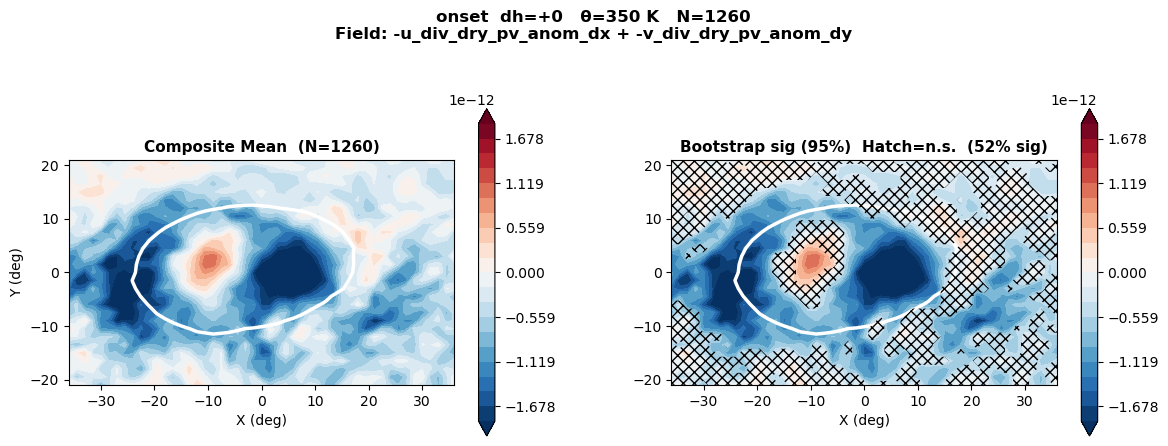

In [6]:
# 6-panel: divergent outflow on 350 K with projection
plot_var(["-u_div_dry_pv_anom_dx", "-v_div_dry_pv_anom_dy"],
         dh=0, theta_level=350, projection=False)

Computing bootstrap (N=1260, n_boot=1000, θ=350 K) ...
  Interpolating 1260 events to θ=350 K ...
  47.4% significant at 95%


/tmp/ipykernel_848445/2997814579.py:164: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


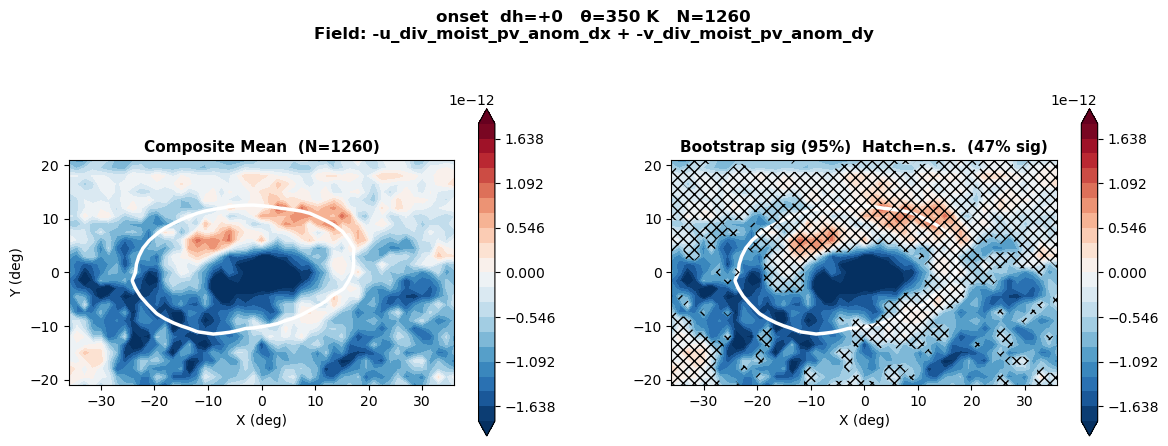

In [7]:
# 6-panel: divergent outflow on 350 K with projection
plot_var(["-u_div_moist_pv_anom_dx", "-v_div_moist_pv_anom_dy"],
         dh=0, theta_level=350, projection=False)

Computing bootstrap (N=1260, n_boot=1000, θ=350 K) ...
  Interpolating 1260 events to θ=350 K ...
  12.6% significant at 95%
  Projection (sig_mask=True): β=9.926e-07  αx=-0.339  αy=0.614  γ=-6.511e+05


/tmp/ipykernel_848445/2997814579.py:164: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


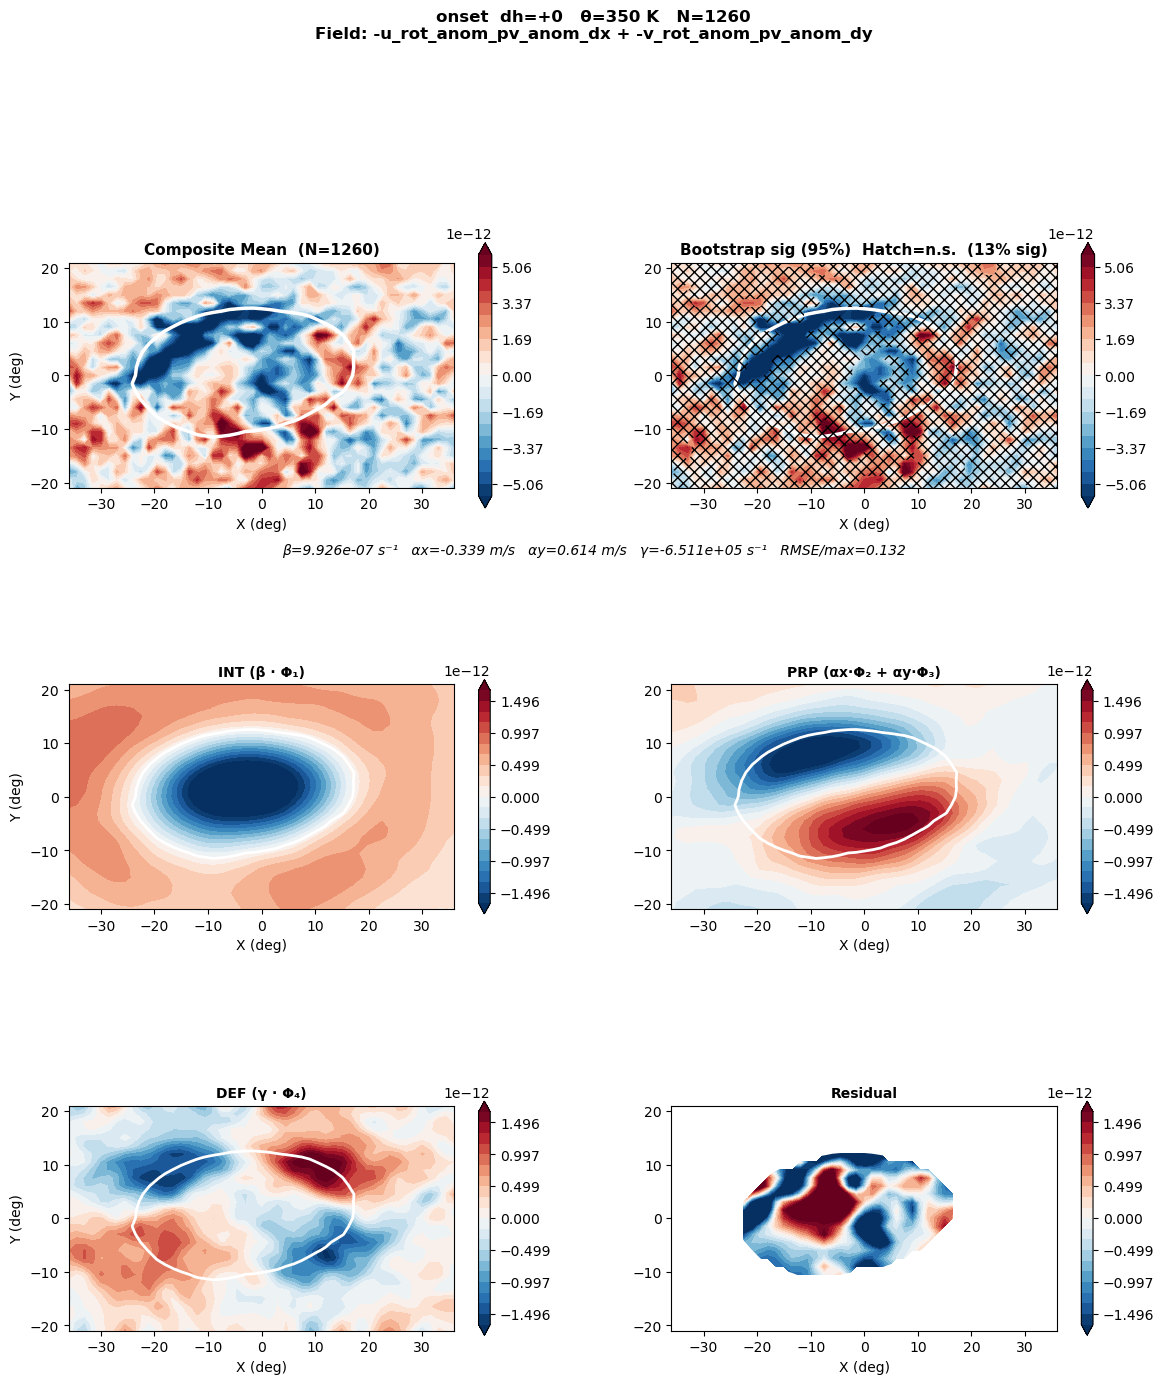

{'beta': 9.926174908633802e-07,
 'ax': -0.33886086753938266,
 'ay': 0.6136673000318557,
 'gamma': -651061.6420518445,
 'gamma_km2': -0.6510616420518445,
 'beta_raw': 9.926174908633802e-13,
 'ax_raw': -3.388608675393827e-13,
 'ay_raw': 6.136673000318556e-13,
 'gamma_raw': -6.510616420518445e-13,
 'prop': array([[-1.55191442e-13, -2.10737390e-13, -2.84101165e-13, ...,
         -1.06093796e-13, -9.43187802e-14, -9.24506022e-14],
        [-1.43400882e-13, -1.81788033e-13, -2.51426337e-13, ...,
         -8.39312775e-14, -6.75494011e-14, -6.51608971e-14],
        [-1.01140351e-13, -1.12494202e-13, -1.58974508e-13, ...,
         -9.86768311e-14, -7.43213851e-14, -6.50795408e-14],
        ...,
        [ 3.27328039e-13,  3.31320563e-13,  3.38303660e-13, ...,
         -1.11194053e-13, -8.93473640e-14, -7.35061818e-14],
        [ 3.73893099e-13,  3.62737625e-13,  3.50484675e-13, ...,
         -4.74156101e-14, -5.09961481e-14, -2.48398570e-14],
        [ 3.85195880e-13,  3.78177931e-13,  3.5654770

In [8]:
# 6-panel: rotational eddy advection on 350 K
plot_var(["-u_rot_anom_pv_anom_dx", "-v_rot_anom_pv_anom_dy"],
         dh=0, theta_level=350, projection=True)

Computing bootstrap (N=1260, n_boot=1000, θ=350 K) ...
  Interpolating 1260 events to θ=350 K ...
  69.6% significant at 95%


/tmp/ipykernel_848445/2997814579.py:164: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


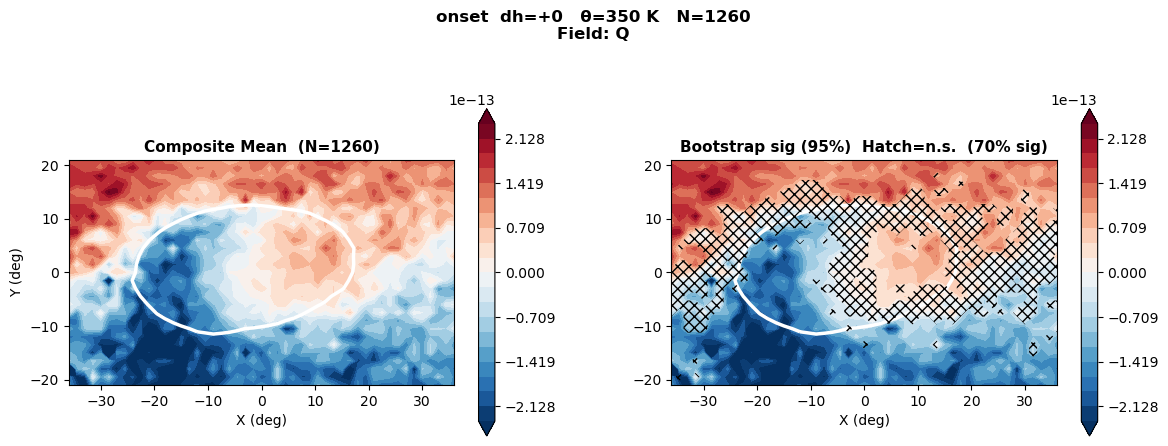

In [9]:
# 6-panel: diabatic Q on 350 K
plot_var(["Q"], dh=0, theta_level=350, projection=False)

Computing bootstrap (N=1260, n_boot=1000, θ=330 K) ...
  Interpolating 1260 events to θ=330 K ...
  62.6% significant at 95%


/tmp/ipykernel_848445/2997814579.py:164: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


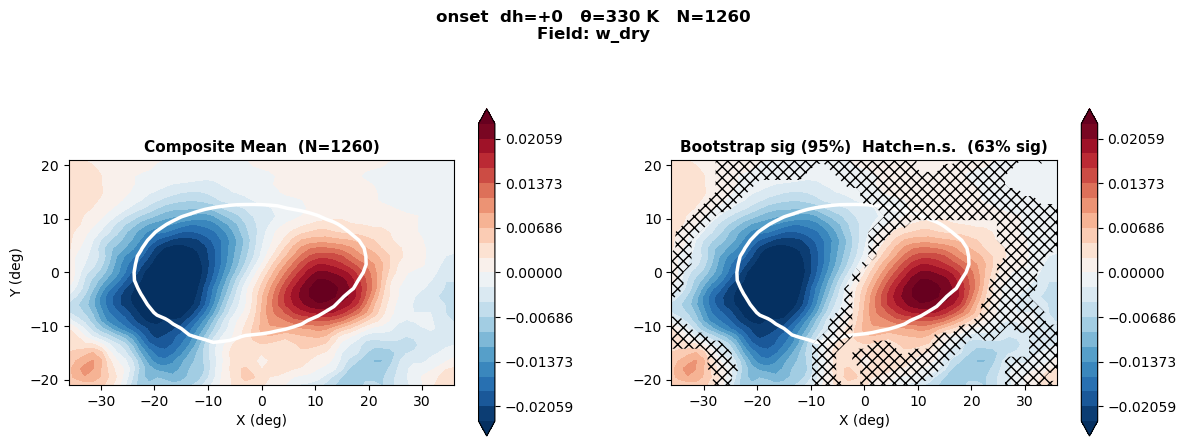

In [13]:
# 6-panel: planetary vorticity advection on 350 K
plot_var(["w_dry"], dh=0, theta_level=330, projection=False)

Computing bootstrap (N=1260, n_boot=1000, θ=330 K) ...
  Interpolating 1260 events to θ=330 K ...
  39.6% significant at 95%


/tmp/ipykernel_848445/2997814579.py:164: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


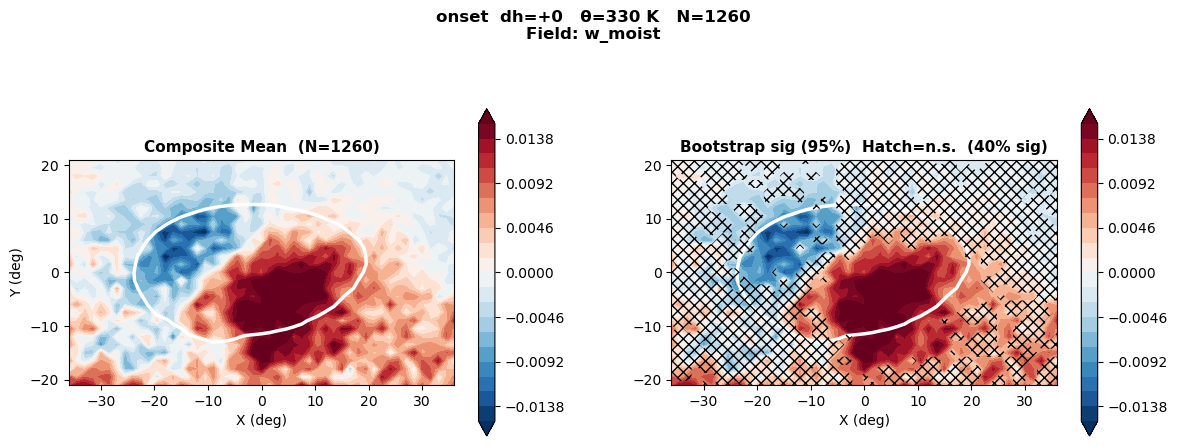

In [14]:
# 6-panel: planetary vorticity advection on 350 K
plot_var(["w_moist"], dh=0, theta_level=330, projection=False)

Computing bootstrap (N=1260, n_boot=1000, θ=350 K) ...
  Interpolating 1260 events to θ=350 K ...
  29.6% significant at 95%
  Projection (sig_mask=True): β=5.841e-07  αx=-0.038  αy=-0.325  γ=1.270e+05


/tmp/ipykernel_848445/2997814579.py:164: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


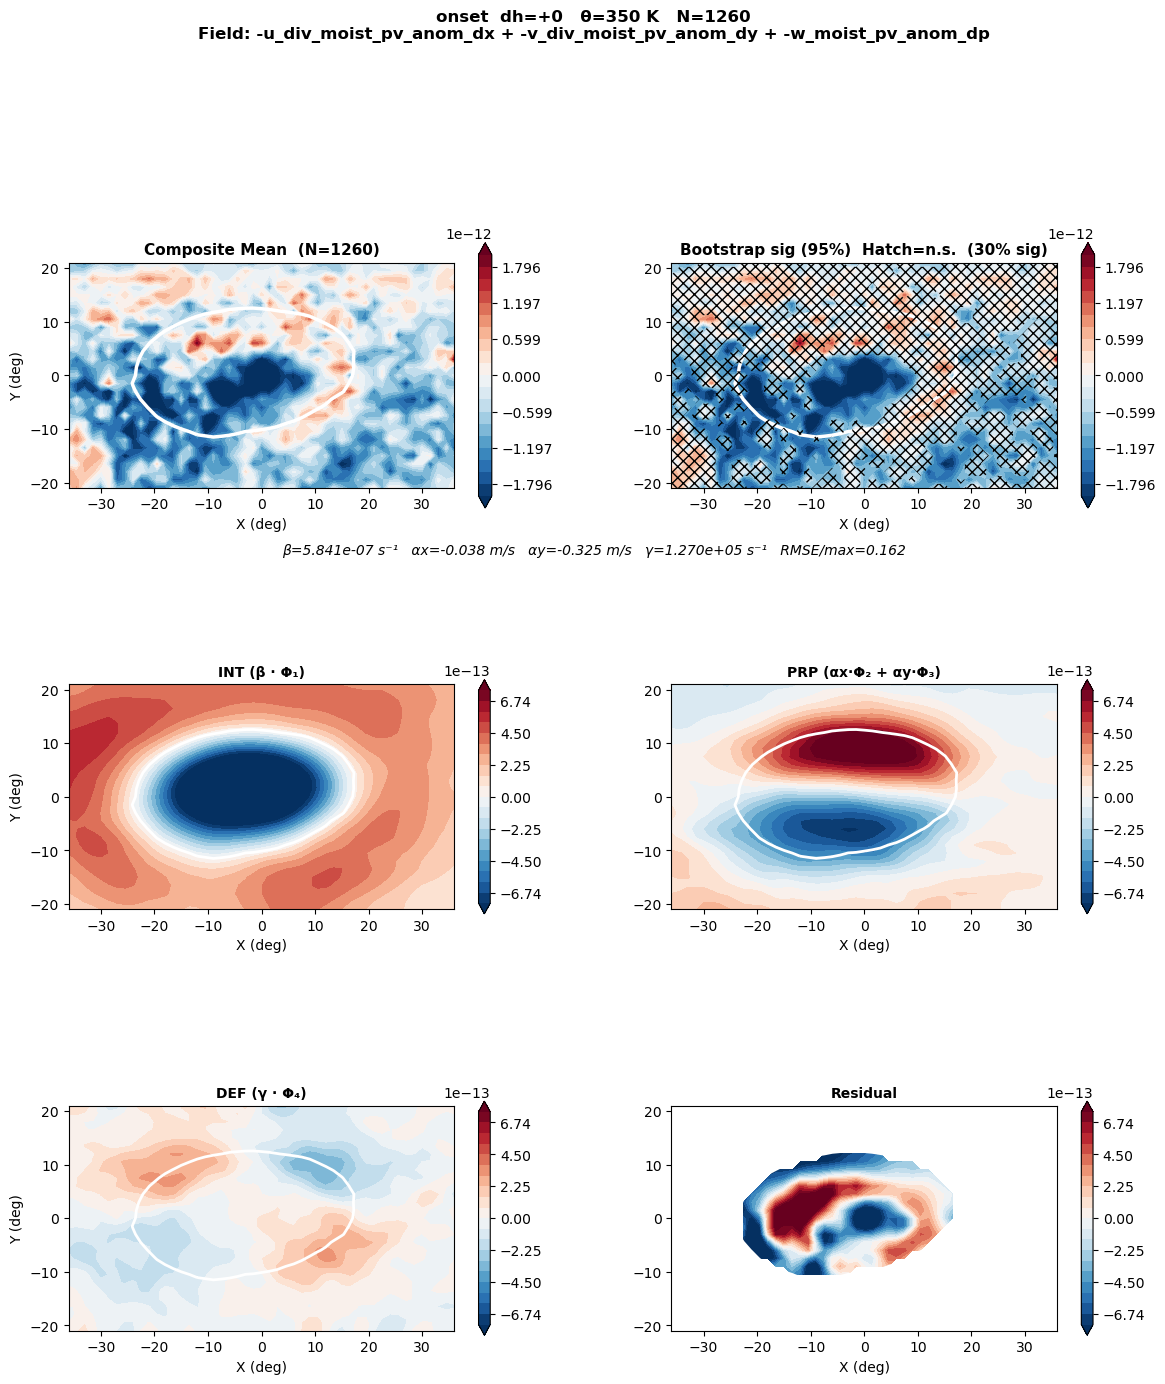

{'beta': 5.840623492372073e-07,
 'ax': -0.037641851204072575,
 'ay': -0.3249142056808648,
 'gamma': 127014.27473141495,
 'gamma_km2': 0.12701427473141494,
 'beta_raw': 5.840623492372073e-13,
 'ax_raw': -3.764185120407257e-14,
 'ay_raw': -3.2491420568086483e-13,
 'gamma_raw': 1.2701427473141495e-13,
 'prop': array([[ 1.72643170e-13,  1.77591004e-13,  1.93647888e-13, ...,
          5.31357182e-14,  5.26271341e-14,  4.90862164e-14],
        [ 1.70742500e-13,  1.77876486e-13,  1.95426710e-13, ...,
          3.74346694e-14,  3.38187112e-14,  2.89670493e-14],
        [ 1.49587330e-13,  1.52633908e-13,  1.61918918e-13, ...,
          4.19518875e-14,  3.05282749e-14,  1.84838561e-14],
        ...,
        [-1.17187798e-13, -1.18020629e-13, -1.20800367e-13, ...,
         -3.47104061e-14, -4.44050164e-14, -5.22028667e-14],
        [-1.20630291e-13, -1.20217861e-13, -1.18057809e-13, ...,
         -7.92783964e-14, -8.04163620e-14, -8.12989691e-14],
        [-1.04112063e-13, -1.03578058e-13, -1.001

In [12]:
# 6-panel: moist-divergent + vertical eddy-eddy on 350 K
plot_var(["-u_div_moist_pv_anom_dx", "-v_div_moist_pv_anom_dy",
          "-w_moist_pv_anom_dp"], dh=0, theta_level=350, projection=True)